# Coins and dice

<img src="https://risk-engineering.org/static/img/logo-RE.png" width="100" alt="" style="float:right;margin:15px;">


This notebook is an element of the free [risk-engineering.org courseware](https://risk-engineering.org/). It can be distributed under the terms of the [Creative Commons Attribution-ShareAlike licence](https://creativecommons.org/licenses/by-sa/4.0/). 

Author: Eric Marsden <eric.marsden@risk-engineering.org>. 

---

In this notebook, we illustrate NumPy features for working with discrete probability distributions, such as those resulting from a coin toss or a dice roll. We also show how to use the [SymPy symbolic mathematics library](https://sympy.org/) to analyze probability problems analytically.
See the [associated course materials](https://risk-engineering.org/statistical-modelling/) for background information and to download this content as a Jupyter notebook.

We start by importing a number of Python libraries and setting up some configuration settings. 

In [1]:
%matplotlib inline

import numpy
import scipy.stats
import matplotlib.pyplot as plt
plt.style.use("bmh")
%config InlineBackend.figure_formats=["svg"]
numpy.set_printoptions(threshold=20)

When undertaking statistical analyses, it can be important for your results to be *reproducible*, meaning that you obtain the same results each time you run the analysis. The pseudorandom number generator used by NumPy generates long sequences of outputs that are fully determined by the *seed* of the generator (if you use the same seed, you will obtain the same results each time you run the notebook). In default setting, the seed is taken from some unpredictable feature of the computer environment (such as the `/dev/random` device on a Linux/Unix computer), so sucessive runs will generate different results. If you want a reproducible notebook, you can set the random seed explicitly. 

In [2]:
numpy.random.seed(42)

Let’s **simulate a coin toss** by a random choice between the numbers 0 and 1 (say 0 represents tails and 1 represents heads). Note that the second argument to `randint` is an *exclusive* upper bound.

In [3]:
numpy.random.randint(0, 2)

0

Let’s toss two coins, which gives as an array with the result of the first and second toss.

In [4]:
numpy.random.randint(0, 2, 2)

array([1, 0])

The number of heads when tossing a coin twice is simply the sum of that array.

In [5]:
numpy.random.randint(0, 2, 2).sum()

0

**Task**: simulate the *number of heads when tossing a coin twice*. Do this 1000 times, calculate the expected value of the number of heads, and plot the distribution of results (the Probability Mass Function).

In [6]:
N = 1000
heads = numpy.zeros(N, dtype=int)
for i in range(N):
    heads[i] = numpy.random.randint(0, 2, 2).sum()
heads

array([1, 0, 1, ..., 0, 2, 2])

The **expected value** (or mathematical expectation) of the number of heads is simply the mean of our observations (it’s what happens “on average”). 

In [7]:
heads.mean()

0.987

Now let’s look at the **distribution** of the number of heads obtained. Let’s count how many times we have scored 0, 1 or 2 in our 1000 simulations, using the `unique` function from `numpy`, then plot that probability mass function. 

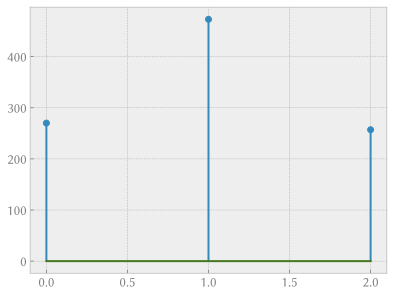

In [8]:
values, counts = numpy.unique(heads, return_counts=True)
plt.stem(values, counts)
plt.show()

The SymPy library, which adds symbolic mathematics capabilities to Python, has functionality that allows us to calculate the expected number of heads and the probability distribution **analytically**.

In [9]:
import sympy.stats
from sympy.interactive import printing
printing.init_printing(use_latex="mathjax")

toss1 = sympy.stats.Bernoulli("toss1", p=0.5)
toss2 = sympy.stats.Bernoulli("toss2", p=0.5)
sympy.stats.E(toss1 + toss2)

1.00000000000000

So the **expected value** of the number of heads is 1 (the numerical approximation we estimated using our simulation above was very close to that). Now let’s examine the **probability distribution**. 

In [10]:
sympy.stats.density(toss1 + toss2)

{0: 0.25, 1: 0.5, 2: 0.25}

## Expected value of a dice roll

The expected value of a dice roll is 

$$\sum_{i=1}^6 i \times \frac{1}{6} = 3.5$$

That means that if we toss a dice a large number of times, the mean value should converge to 3.5. Let’s check that empirically by running a simulation in Python.

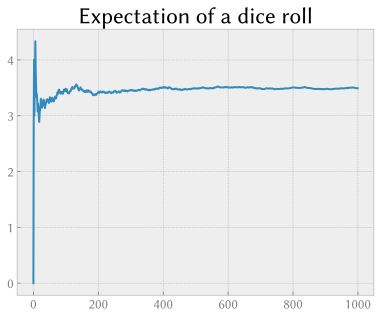

In [11]:
N = 1000
roll = numpy.zeros(N, dtype=int)
expectation = numpy.zeros(N)
for i in range(N):
    roll[i] = numpy.random.randint(1, 7)
for i in range(1, N):
    expectation[i] = numpy.mean(roll[0:i])
plt.plot(expectation)
plt.title("Expectation of a dice roll")
plt.show()

The sympy.stats module has functionality that allows us to evaluate the expected value analytically. 

In [12]:
D = sympy.stats.Die("D", 6)
sympy.stats.E(D)

7/2

## Simulating dice throws

In [13]:
dice = scipy.stats.randint(1, 7)
dice.rvs(1000).max()

6

We simulated a thousand dice throws, and never rolled anything bigger than a 6 (that’s reassuring!).

What is the probability of a die rolling 4?

In [14]:
dice.pmf(4)

0.16666666666666666

What is the probability of rolling 4 or below?

In [15]:
dice.cdf(4)

0.6666666666666666

What is the probability of rolling between 2 and 4 (inclusive)?

In [16]:
dice.cdf(4) - dice.cdf(1)

0.5

Again, using `sympy.stats` to calculate this analytically:

The probability of a dice roll of 4:

In [17]:
sympy.stats.P(sympy.Eq(D, 4))

1/6

Probability of rolling 4 or below:

In [18]:
sympy.stats.P(D <= 4)

2/3

Probability of rolling between 2 and 4 (inclusive):

In [19]:
sympy.stats.P(sympy.And(D >= 2, D <= 4))

1/2

Now let’s look at what happens when we roll **three dice**. We’ll estimate the expected value and the probability mass function for the sum of three dice.  

In [20]:
N = 10_000
roll = numpy.zeros(N, dtype=int)
for i in range(N):
    roll[i] = scipy.stats.randint(1, 7).rvs(3).sum()
roll.mean()

10.5018

We can plot the probability mass function for the sum of three dice:

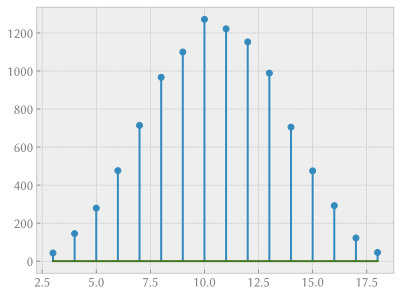

In [21]:
values, counts = numpy.unique(roll, return_counts=True)
plt.stem(values, counts)
plt.show()

The SymPy library allows us to calculate the expectation and probability distribution **analytically**. 

In [22]:
D1 = sympy.stats.Die("D1", 6)
D2 = sympy.stats.Die("D2", 6)
D3 = sympy.stats.Die("D3", 6)
Z = D1 + D2 + D3
sympy.stats.E(Z)

21/2

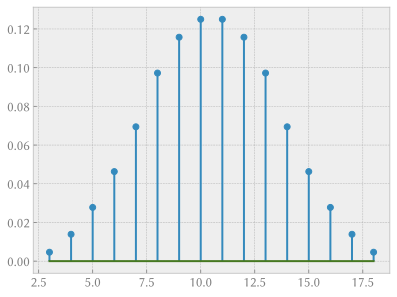

In [23]:
pmf = sympy.stats.density(Z)
# need to explicitly cast keys and values to float type, because
# matplotlib can't handle some SymPy values
keys = [float(k) for k in pmf.keys()]
vals = [float(pmf[k]) for k in keys]
plt.stem(keys, vals)
plt.show()

The SymPy library also allows us to calculate more complicated expressions, such as the probability that the sum of three dice is greater than 10, given that the first throw is bigger than 4. This is called a *conditional probability*.

In [24]:
sympy.stats.P(D1 + D2 + D3 > 10, D1 > 4)

7/9

We can estimate the same value using Python, using a stochastic simulation (or Monte Carlo) approach:

In [25]:
N = 1000
count = 0
hits = 0
while count < N:
    # the second argument to randint is an exclusive upper bound
    roll = scipy.stats.randint(1, 7).rvs(3)
    if roll[0] > 4:
        count += 1
        if roll.sum() > 10:
            hits += 1
hits / float(count)

0.797

## The last banana thought experiment

Consider the following [thought experiment in probability by Leonardo Barichello](https://ed.ted.com/lessons/the-last-banana-a-thought-experiment-in-probability-leonardo-barichello): Two people are stranded on an island with only one banana to eat. To decide who gets it, they agree to play a game. Each of them will roll a fair 6-sided dice. If the largest number rolled is a 1, 2, 3, or 4, then Player 1 gets the banana. If the largest number rolled is a 5 or 6, then Player 2 gets it. Which player has the better chance?

If we are not entirely convinced by our intuition concerning the banana, we can simulate this situation a large number of times, using a stochastic simulation (or Monte Carlo) approach:

In [26]:
N = 1000
player1 = 0
for i in range(N):
    # the second argument to randint is an exclusive upper bound
    roll1 = scipy.stats.randint(1, 7).rvs(1)
    roll2 = scipy.stats.randint(1, 7).rvs(1)
    if max(roll1, roll2) <= 4:
        player1 += 1
player1 / float(N)

0.439

The situation is also easy to resolve analytically: Player 1 gets the banana when both the dice rolls are smaller than 5. The probability of a roll smaller than 5 is 4/6, the two dice rolls are independent events, so their combined probability is the product of their individual probabilities: Player 1 gets the banana with probability

In [27]:
4/6 * 4/6

0.4444444444444444

## The gambles of the Chevalier de Méré

Let’s analyze two problems which were discussed between Antoine Gombaud, chevalier de Méré, a passionate gambler, and the mathematician Blaise Pascal. This discussion was a little daring for the time, because it went against established doctrine of the Catholic church that people should not attempt to predict the future (an activity that was reserved for the deity). The discussion and collaboration of Pascal with another mathematician, Pierre de Fermat, helped in the development of probability theory.

The **first problem**: *is it a good idea to gamble on the appearance of at least one 6 when a dice is thrown 4 times*?

The probability of losing this gamble is easy to calculate analytically: each throw has 5 chances out of 6 of not seeing a 6, and the events are independent. So the probability of winning is

In [28]:
1 - (5/6.0)**4

0.5177469135802468

The probability of winning is greater than 0.5. We can also check this problem with SymPy:

In [29]:
import sympy.stats

D1 = sympy.stats.Die("D1", 6)
D2 = sympy.stats.Die("D2", 6)
D3 = sympy.stats.Die("D3", 6)
D4 = sympy.stats.Die("D4", 6)

sympy.stats.P(sympy.Or(D1 > 5, sympy.Or(D2 > 5, sympy.Or(D3 > 5, D4 > 5)))) + 0.0

0.517746913580247

The **second problem**: *is it a good idea to gamble on the appearance of at least one double six when two dice are thrown 24 times*? 

The probability of losing this gamble is also easy to calculate: there are 35 chances out of 36 (6 * 6) of not seeing a double 6 on each double throw, so the probability of winning is

In [30]:
1 - (35/36.0)**24

0.4914038761309034

So this is not a good gamble. We can also calculate this analytically with SymPy, by modelling a Binomial random variable:

In [31]:
A = sympy.stats.Die("A", 6)
B = sympy.stats.Die("B", 6)
doublesix = sympy.stats.Binomial("DoubleSix", 24, sympy.stats.P(sympy.And(A > 5, B > 5)))
sympy.stats.P(doublesix >= 1) + 0.0

0.491403876130903

**Exercise**: write some Python code to simulate this gamble and check that you obtain a similar probability. 

## Pepys and Newton

Samuel Pepys was a great diarist of the English language and a friend of Isaac Newton’s. Pepys was a gambler and [wrote to Newton](https://en.wikipedia.org/wiki/Newton%E2%80%93Pepys_problem) to ask which of three events is the most likely:

1. at least one six comes up when six fair dice are rolled;
2. at least two sixes come up when 12 dice are rolled;
3. at least three sixes come up when 18 dice are rolled.

Now Newton wasn’t able to use Python, and spent a while working out the answers, but we can [stand on the shoulders of giants](https://en.wikipedia.org/wiki/Standing_on_the_shoulders_of_giants) and figure this out quite easily.  

**Possibility 1**: the probability of rolling at least one six is 1 minus the probability of zero sixes, which is

In [32]:
1 - (5/6.0)**6

0.6651020233196159

**Possibility 2**: the probability of at least two sixes is 1 minus the probability of zero sixes, minus the probability of a single six. The probability of zero sixes is easy to calculate; here are three ways of calculating it.

In [33]:
# throw a non-6 12 times
(5/6.0)**12

0.11215665478461515

In [34]:
# probability mass at 0 of a binomial distribution with n=18, p=1/6
scipy.stats.binom(12, 1/6.0).pmf(0)

0.11215665478461513

In [35]:
# a symbolic representation of the same binomial distribution as above
D12 = sympy.stats.Binomial("18dice", 12, 1/6)
sympy.stats.P(sympy.Eq(D12, 0))

0.112156654784615

The probability of rolling a single six can likewise be determined using the binomial distribution.

In [36]:
scipy.stats.binom(12, 1/6.0).pmf(1)

0.2691759714830762

so the final answer is

In [37]:
roll12 = scipy.stats.binom(12, 1/6.0)
1 - roll12.pmf(0) - roll12.pmf(1)

0.6186673737323087

**Possibility 3**: in the same way, the probability of at least three sixes when rolling 18 dice is one minus the probability of zero sixes, minus the probability of one six, minus the probability of two sixes.

In [38]:
roll18 = scipy.stats.binom(18, 1/6.0)
1 - roll18.pmf(0) - roll18.pmf(1) - roll18.pmf(2)

0.5973456859477231

In [39]:
1 - roll18.cdf(2)

0.5973456859477229

Conclusion: it’s best to bet on possibility 1.

## Dice throws in Dungeons and dragons

[Dungeons and dragons](https://en.wikipedia.org/wiki/Dungeons_%26_Dragons) is a well-known role-playing game, where dice throws are widely used to determine evolution of the game. For example, a dice throw might determine the level of damage generated by some game action. 

A [question you might ask yourself](https://boredzo.org/blog/archives/2020-01-25/probability-distribution-of-multiplied-dice-rolls) when playing: Is there any difference between rolling 1d8×2 (that is, rolling exactly one d8 and multiplying the result by 2) and rolling 2d8 (that is, rolling exactly two d8s and not modifying the result)?

Intuitively, you might think these will result in similar probability distributions (if you think a little, the 1d8x2 is obviously not going to generate any odd values, unlike 2d8). Actually, they are very different! 

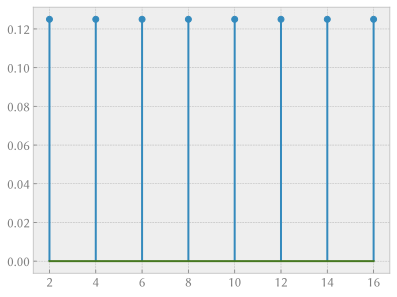

In [40]:
# roll one dice and multiply by two
D8 = sympy.stats.Die("D8", 8)
pmf = sympy.stats.density(D8 * 2)
keys = [float(k) for k in pmf.keys()]
vals = [float(pmf[k]) for k in keys]
plt.stem(keys, vals)
plt.show()

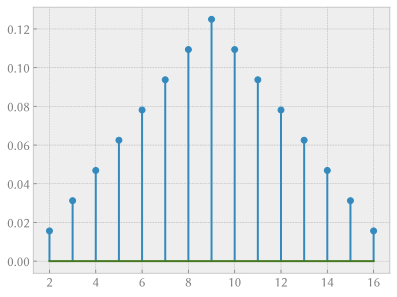

In [41]:
# roll two dice and sum
D8A = sympy.stats.Die("D8A", 8)
D8B = sympy.stats.Die("D8B", 8)
pmf = sympy.stats.density(D8A + D8B)
keys = [float(k) for k in pmf.keys()]
vals = [float(pmf[k]) for k in keys]
plt.stem(keys, vals)
plt.show()